# Q5 ML Signal Generation Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom backtesting framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework uses machine learning and walk-forward validation to predict the price trend in the next 5 days as a trading strategy to either buy, hold, or sell. It uses three different ML models, compares them agains a simple MA signal generator (Q1).  



## 2. Data Pipeline

The structure of the data flow is as follows:

The pipeline:

1. Data Download
   
2. Feature Engineering
       
3. Target Variable
   - 5-day forward return, binarized, non-overlapping
     
4. Walk-Forward Validation

5. Model Training

6. Signal Generation on test window

7. Signal Evaluation Metrics

8. Backtesting
  
9. Feature Importance

10. Volume Hypothesis Test — does volume add predictive power beyond price alone?

11. Visualisation

In [ ]:
# ==========================================================
# IMPORTS
# ==========================================================

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score)


# ==========================================================
# PROJECT PATHS
# ==========================================================

PROJECT_DIR = Path.cwd().resolve()

Q5_DIR = (
    PROJECT_DIR
    if (PROJECT_DIR / "ml_trading.py").exists()
    else PROJECT_DIR / "Q5_ml_signal_generation"
)

if not (Q5_DIR / "ml_trading.py").exists():
    raise FileNotFoundError("Could not locate Q5_ml_signal_generation/ml_trading.py")

if str(Q5_DIR) not in sys.path:
    sys.path.insert(0, str(Q5_DIR))

UTILS_DIR = Q5_DIR.parent / "utils"

if str(UTILS_DIR) not in sys.path:
    sys.path.append(
        str(UTILS_DIR)
    )


# ==========================================================
# CUSTOM FUNCTIONS
# ==========================================================

from Q5_ml_signal_generation.ml_trading_old import (select_feature_families, reshape_market_data, build_feature_factory, walk_forward_predict, build_weekly_supervised_dataset, predictions_to_position, performance_summary, generate_uniform_random_decisions, run_random_benchmark_simulations,
                         backtest_position, generate_markov_random_decisions, weekly_decisions_to_daily_position, summarize_random_results, median_random_row, model_factory)

In [2]:
print("Current directory:")
print(Path.cwd())

print("\nUtilities directory:")
print(UTILS_DIR)

print("\nUtilities directory exists:")
print(UTILS_DIR.exists())

Current directory:
/Users/walt/Documents/GitHub/quant-research/Q5_ml_signal_generation

Utilities directory:
/Users/walt/Documents/GitHub/quant-research/utils

Utilities directory exists:
True


In [3]:
# ==========================================================
# LOAD DATA
# ==========================================================

starting_capital = 100_000

lookback_years = 10

ticker = "AAPL"

end = (pd.Timestamp.today(tz="UTC").normalize())

start = end - pd.DateOffset(years=lookback_years)

ohlcv = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

# Flatten yfinance MultiIndex if necessary
if isinstance(ohlcv.columns, pd.MultiIndex):
    ohlcv.columns = ohlcv.columns.get_level_values(0)

ohlcv = (ohlcv.reset_index())


## 3. Feature engineering

In [4]:
# ==========================================================
# CELL 3 — WEEKLY SUPERVISED DATASET
# ==========================================================

LOOKBACK = 25

BUY_THRESHOLD = 0.030
SELL_THRESHOLD = -0.020

TRANSACTION_COST = 0.001
# Per side:
# 0.001 = 0.10%
# 0.010 = 1.00%


# ----------------------------------------------------------
# Create daily feature source
#
# The target generated here is irrelevant. We only need the
# daily lag structure and feature factory output.
# ----------------------------------------------------------

daily_supervised = reshape_market_data(
    df=ohlcv,
    lookback=LOOKBACK,
    prediction_horizon=1,
    classification_threshold=0.0,
)

featured_daily, feature_families = (
    build_feature_factory(
        daily_supervised
    )
)


# ----------------------------------------------------------
# Select V1 feature families
#
# Returns + distribution was the strongest controlled
# experiment in the earlier version.
# ----------------------------------------------------------

selected_families = [
    "base_returns",
    "distribution",
]

model_features = []

for family_name in selected_families:
    model_features.extend(
        feature_families[family_name]
    )

model_features = list(
    dict.fromkeys(model_features)
)


# ----------------------------------------------------------
# Build weekly open-to-next-open supervised observations
# ----------------------------------------------------------

weekly_data = build_weekly_supervised_dataset(
    ohlcv=ohlcv,
    featured_daily=featured_daily,
    feature_columns=model_features,
    buy_threshold=BUY_THRESHOLD,
    sell_threshold=SELL_THRESHOLD,
)


# ----------------------------------------------------------
# Inspection
# ----------------------------------------------------------

print("=" * 70)
print("WEEKLY DATASET CONFIGURATION")
print("=" * 70)

print(f"Ticker:              {ticker}")
print(f"Daily lookback:      {LOOKBACK} sessions")
print(f"Buy threshold:       {BUY_THRESHOLD:.2%}")
print(f"Sell threshold:      {SELL_THRESHOLD:.2%}")
print(f"Transaction cost:    {TRANSACTION_COST:.2%} per side")
print(f"Feature families:    {selected_families}")
print(f"Model features:      {len(model_features)}")

print("\nWeekly observations:")
print(f"Rows:                {len(weekly_data)}")

print(
    f"Decision-date range: "
    f"{weekly_data['decision_date'].min().date()} "
    f"→ "
    f"{weekly_data['decision_date'].max().date()}"
)

print("\nTarget counts:")
print(
    weekly_data["target"]
    .value_counts()
    .sort_index()
)

print("\nTarget proportions:")
print(
    weekly_data["target"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nFuture weekly return statistics:")
display(
    weekly_data["future_week_return"]
    .describe()
    .to_frame("future_week_return")
)

print("\nAlignment preview:")
display(
    weekly_data[
        [
            "feature_date",
            "decision_date",
            "entry_open",
            "next_decision_date",
            "next_entry_open",
            "future_week_return",
            "target",
        ]
    ].head(15)
)

WEEKLY DATASET CONFIGURATION
Ticker:              AAPL
Daily lookback:      25 sessions
Buy threshold:       3.00%
Sell threshold:      -2.00%
Transaction cost:    0.10% per side
Feature families:    ['base_returns', 'distribution']
Model features:      41

Weekly observations:
Rows:                515
Decision-date range: 2016-08-29 → 2026-07-06

Target counts:
target
-1    111
 0    289
 1    115
Name: count, dtype: int64

Target proportions:
target
-1    0.215534
 0    0.561165
 1    0.223301
Name: proportion, dtype: float64

Future weekly return statistics:


,future_week_return
count,515.000000
mean,0.005788
std,0.040040
min,-0.183448
25%,-0.016384
50%,0.006398
75%,0.026234
max,0.193228



Alignment preview:


Price,feature_date,decision_date,entry_open,next_decision_date,next_entry_open,future_week_return,target
0,2016-08-26,2016-08-29,24.403491,2016-09-06,24.696466,0.012005,0
1,2016-09-02,2016-09-06,24.696466,2016-09-12,23.494822,-0.048656,-1
2,2016-09-09,2016-09-12,23.494822,2016-09-19,26.365019,0.122163,1
3,2016-09-16,2016-09-19,26.365019,2016-09-26,25.552487,-0.030819,-1
4,2016-09-23,2016-09-26,25.552487,2016-10-03,25.797396,0.009585,0
5,2016-09-30,2016-10-03,25.797396,2016-10-10,26.326108,0.020495,0
6,2016-10-07,2016-10-10,26.326108,2016-10-17,26.854827,0.020083,0
7,2016-10-14,2016-10-17,26.854827,2016-10-24,26.802184,-0.001960,0
8,2016-10-21,2016-10-24,26.802184,2016-10-31,26.012539,-0.029462,-1
9,2016-10-28,2016-10-31,26.012539,2016-11-07,25.324786,-0.026439,-1


In [5]:
# ==========================================================
# WEEKLY RETURN THRESHOLD DIAGNOSTICS
# ==========================================================

weekly_returns = (
    weekly_data["future_week_return"]
    .dropna()
)

positive_returns = weekly_returns[
    weekly_returns > 0
]

negative_returns = weekly_returns[
    weekly_returns < 0
]

threshold_diagnostics = pd.DataFrame({
    "all_returns": weekly_returns.describe(),
    "positive_returns": positive_returns.describe(),
    "negative_returns": negative_returns.describe(),
})

print("=" * 70)
print("WEEKLY RETURN DISTRIBUTION")
print("=" * 70)

display(threshold_diagnostics)


summary = pd.DataFrame({
    "group": [
        "Positive weeks",
        "Negative weeks",
    ],
    "count": [
        len(positive_returns),
        len(negative_returns),
    ],
    "mean": [
        positive_returns.mean(),
        negative_returns.mean(),
    ],
    "median": [
        positive_returns.median(),
        negative_returns.median(),
    ],
    "q25": [
        positive_returns.quantile(0.25),
        negative_returns.quantile(0.25),
    ],
    "q75": [
        positive_returns.quantile(0.75),
        negative_returns.quantile(0.75),
    ],
})

display(
    summary.style.format({
        "mean": "{:.2%}",
        "median": "{:.2%}",
        "q25": "{:.2%}",
        "q75": "{:.2%}",
    })
)


print("\nCurrent thresholds")
print(f"Buy:     > {BUY_THRESHOLD:.2%}")
print(f"Sell:    < {SELL_THRESHOLD:.2%}")
print("Neutral: otherwise")

print("\nClass proportions under current thresholds:")

current_classes = np.select(
    [
        weekly_returns < SELL_THRESHOLD,
        weekly_returns > BUY_THRESHOLD,
    ],
    [
        -1,
        1,
    ],
    default=0,
)

print(
    pd.Series(current_classes)
    .value_counts(normalize=True)
    .sort_index()
)

WEEKLY RETURN DISTRIBUTION


,all_returns,positive_returns,negative_returns
count,515.000000,299.000000,216.000000
mean,0.005788,0.030608,-0.028569
std,0.040040,0.027974,0.026564
min,-0.183448,0.000089,-0.183448
25%,-0.016384,0.011158,-0.040405
50%,0.006398,0.023619,-0.021107
75%,0.026234,0.041515,-0.009450
max,0.193228,0.193228,-0.000339


,group,count,mean,median,q25,q75
0,Positive weeks,299,3.06%,2.36%,1.12%,4.15%
1,Negative weeks,216,-2.86%,-2.11%,-4.04%,-0.95%



Current thresholds
Buy:     > 3.00%
Sell:    < -2.00%
Neutral: otherwise

Class proportions under current thresholds:
-1    0.215534
 0    0.561165
 1    0.223301
Name: proportion, dtype: float64


## 4. Model training

In [6]:
# ==========================================================
# CELL 4 — FEATURE SELECTION + WALK-FORWARD MODEL
# ==========================================================

selected_families = [
    "base_returns",
    "distribution",
]

model_features = []

for family_name in selected_families:
    model_features.extend(
        feature_families[family_name]
    )

model_features = list(
    dict.fromkeys(model_features)
)


missing_model_features = [
    column
    for column in model_features
    if column not in weekly_data.columns
]

if missing_model_features:
    raise KeyError(
        "The following selected features are missing from "
        f"df_sampled:\n{missing_model_features}"
    )


print("Selected feature families:")

for family_name in selected_families:
    print(
        f"{family_name:<15}: "
        f"{len(feature_families[family_name])} features"
    )

print(f"\nTotal model features: {len(model_features)}")





predictions, fold_metrics = walk_forward_predict(
    data=weekly_data,
    feature_columns=model_features,
    target_column="target",
    date_column="decision_date",
    model_factory=model_factory,
    initial_train_size=0.50,
    validation_size=0.10,
)

print("\nWalk-forward model completed.")
print(f"Out-of-sample predictions: {len(predictions)}")
print(f"Validation folds: {len(fold_metrics)}")

Selected feature families:
base_returns   : 25 features
distribution   : 16 features

Total model features: 41

Walk-forward model completed.
Out-of-sample predictions: 258
Validation folds: 6


/Users/walt/Documents/GitHub/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 5. Compute metrics

In [7]:
# ==========================================================
# CELL 5 — MODEL EVALUATION
# ==========================================================

# ----------------------------------------------------------
# Fold-level metrics
# ----------------------------------------------------------

print("=" * 70)
print("FOLD METRICS")
print("=" * 70)

display(
    fold_metrics[
        [
            "fold",
            "train_start",
            "train_end",
            "validation_start",
            "validation_end",
            "train_rows",
            "validation_rows",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
)


# ----------------------------------------------------------
# Aggregate metrics
#
# We calculate both:
# 1. Mean fold metrics: every fold gets equal weight.
# 2. Pooled metrics: every prediction gets equal weight.
#
# The pooled metrics are more representative here because the
# final fold contains only a few observations.
# ----------------------------------------------------------

mean_fold_metrics = (
    fold_metrics[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
        ]
    ]
    .mean()
)

pooled_accuracy = accuracy_score(
    predictions["actual"],
    predictions["prediction"],
)

pooled_balanced_accuracy = balanced_accuracy_score(
    predictions["actual"],
    predictions["prediction"],
)

pooled_macro_f1 = f1_score(
    predictions["actual"],
    predictions["prediction"],
    average="macro",
)

summary_metrics = pd.DataFrame(
    {
        "mean_fold_metric": [
            mean_fold_metrics["accuracy"],
            mean_fold_metrics["balanced_accuracy"],
            mean_fold_metrics["macro_f1"],
        ],
        "pooled_oos_metric": [
            pooled_accuracy,
            pooled_balanced_accuracy,
            pooled_macro_f1,
        ],
    },
    index=[
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ],
)

print("\n" + "=" * 70)
print("SUMMARY METRICS")
print("=" * 70)

display(summary_metrics)


# ----------------------------------------------------------
# Class distributions
# ----------------------------------------------------------

class_distribution = pd.DataFrame({
    "actual": (
        predictions["actual"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "prediction": (
        predictions["prediction"]
        .value_counts(normalize=True)
        .sort_index()
    ),
}).fillna(0)

class_distribution.index.name = "class"

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

display(class_distribution)


# ----------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------

confusion = pd.DataFrame(
    confusion_matrix(
        predictions["actual"],
        predictions["prediction"],
        labels=[-1, 0, 1],
    ),
    index=[
        "Actual -1",
        "Actual 0",
        "Actual 1",
    ],
    columns=[
        "Predicted -1",
        "Predicted 0",
        "Predicted 1",
    ],
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

display(confusion)


# ----------------------------------------------------------
# Per-class report
# ----------------------------------------------------------

classification = pd.DataFrame(
    classification_report(
        predictions["actual"],
        predictions["prediction"],
        labels=[-1, 0, 1],
        target_names=[
            "Down <-2%",
            "Neutral",
            "Up >2%",
        ],
        output_dict=True,
        zero_division=0,
    )
).T

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

display(classification)


# ----------------------------------------------------------
# Prediction preview
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("DATED OUT-OF-SAMPLE PREDICTIONS")
print("=" * 70)

display(
    predictions.head(10)
)

FOLD METRICS


,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,accuracy,balanced_accuracy,macro_f1
0,1,2016-08-29,2021-07-26,2021-08-02,2022-07-18,257,51,0.411765,0.312077,0.232323
1,2,2016-08-29,2022-07-18,2022-07-25,2023-07-10,308,51,0.568627,0.422244,0.394640
2,3,2016-08-29,2023-07-10,2023-07-17,2024-07-01,359,51,0.529412,0.310345,0.230769
3,4,2016-08-29,2024-07-01,2024-07-08,2025-06-23,410,51,0.450980,0.294872,0.215962
4,5,2016-08-29,2025-06-23,2025-06-30,2026-06-15,461,51,0.607843,0.333333,0.258333
5,6,2016-08-29,2026-06-15,2026-06-22,2026-07-06,512,3,0.000000,0.000000,0.000000



SUMMARY METRICS


,mean_fold_metric,pooled_oos_metric
accuracy,0.428105,0.507752
balanced_accuracy,0.278812,0.338477
macro_f1,0.222005,0.274124



CLASS DISTRIBUTION


...

,Predicted -1,Predicted 0,Predicted 1
Actual -1,2,57,5
Actual 0,7,126,2
Actual 1,6,50,3



CLASSIFICATION REPORT


,precision,recall,f1-score,support
Down <-2%,0.133333,0.031250,0.050633,64.000000
Neutral,0.540773,0.933333,0.684783,135.000000
Up >2%,0.300000,0.050847,0.086957,59.000000
accuracy,0.507752,0.507752,0.507752,0.507752
macro avg,0.324702,0.338477,0.274124,258.000000
weighted avg,0.384642,0.507752,0.390762,258.000000



DATED OUT-OF-SAMPLE PREDICTIONS


,decision_date,fold,actual,prediction,prob_-1,prob_0,prob_1
0,2021-08-02,1,0,0,0.145354,0.765319,0.089327
1,2021-08-09,1,0,0,0.187528,0.658247,0.154225
2,2021-08-16,1,0,0,0.114477,0.656549,0.228974
3,2021-08-23,1,0,0,0.126263,0.818390,0.055347
4,2021-08-30,1,1,0,0.106425,0.750235,0.143341
5,2021-09-07,1,-1,0,0.124068,0.715802,0.160130
6,2021-09-13,1,-1,0,0.061609,0.852187,0.086204
7,2021-09-20,1,0,0,0.318801,0.471492,0.209707
8,2021-09-27,1,-1,0,0.134120,0.670216,0.195664
9,2021-10-04,1,0,0,0.308353,0.611032,0.080614


## 6. Feature importance

FEATURE IMPORTANCE


,rank,feature,importance,importance_pct,cumulative_pct
0,1,ret_25,123,5.112219,5.112219
1,2,ret_24,115,4.779717,9.891937
2,3,ret_9,96,3.990025,13.881962
3,4,ret_iqr,94,3.906899,17.788861
4,5,ret_2,93,3.865337,21.654198
5,6,ret_21,90,3.740648,25.394846
6,7,ret_3,89,3.699086,29.093932
7,8,ret_19,81,3.366584,32.460515
8,9,ret_17,79,3.283458,35.743973
9,10,ret_15,78,3.241895,38.985869


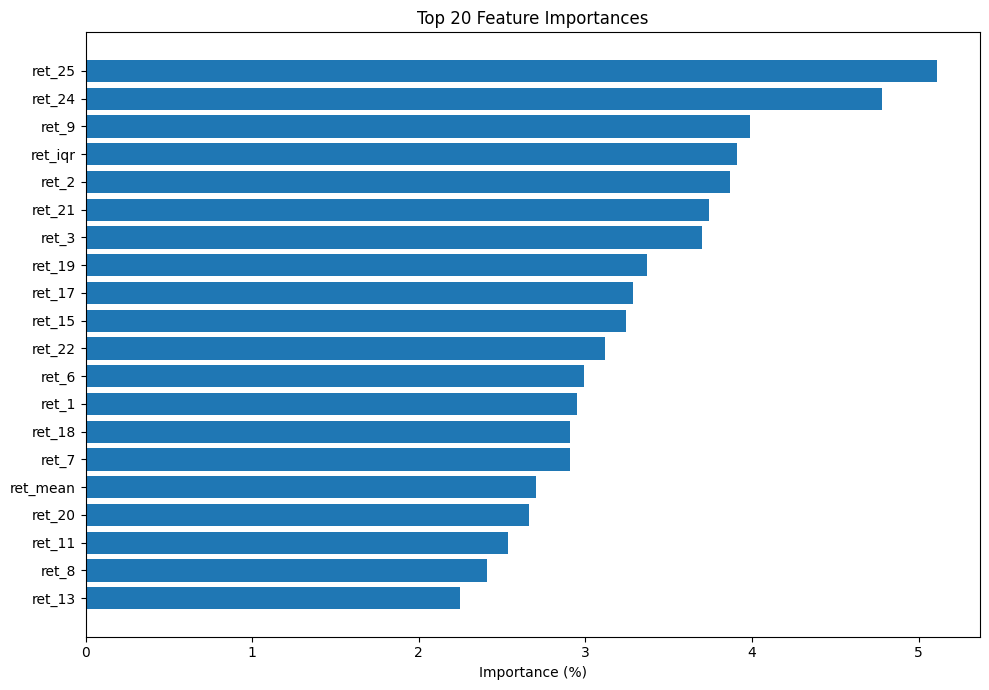

In [8]:
# ==========================================================
# CELL 6 — FEATURE IMPORTANCE
# ==========================================================

importance_model = model_factory()

importance_model.fit(
    weekly_data[model_features],
    weekly_data["target"],
)

importance = (
    pd.DataFrame({
        "feature": model_features,
        "importance": importance_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance["importance_pct"] = (
    100
    * importance["importance"]
    / importance["importance"].sum()
)

importance["cumulative_pct"] = (
    importance["importance_pct"].cumsum()
)

importance.insert(
    0,
    "rank",
    np.arange(1, len(importance) + 1)
)

print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

display(importance.head(20))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

top_n = 20

plt.figure(figsize=(10, 7))

plt.barh(importance.loc[:top_n-1, "feature"][::-1], importance.loc[:top_n-1, "importance_pct"][::-1])

plt.xlabel("Importance (%)")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

## 7. Signal backtesting

In [9]:
# ==========================================================
# CELL 7 — GENERATE TRADING SIGNALS
# ==========================================================

# ----------------------------------------------------------
# Daily close series
# ----------------------------------------------------------

daily_close = (
    ohlcv
    .set_index("Date")["Close"]
    .sort_index()
)





# ----------------------------------------------------------
# Weekly ML decisions
#
# Predictions exist only on the non-overlapping five-day
# sample dates.
# ----------------------------------------------------------

signal_ml_weekly = (
    predictions
    .set_index("decision_date")["prediction"]
    .sort_index()
    .astype(int)
)

position_ml_weekly = predictions_to_position(
    signal=signal_ml_weekly,
    initial_position=0,
)


# ----------------------------------------------------------
# Expand weekly ML state to the daily trading calendar
#
# Each decision remains active until the next prediction date.
# ----------------------------------------------------------

signal_ml_daily = (
    signal_ml_weekly
    .reindex(daily_close.index)
    .ffill()
    .fillna(0)
    .astype(int)
)

position_ml = (
    position_ml_weekly
    .reindex(daily_close.index)
    .ffill()
    .fillna(0)
    .astype(int)
)


# ----------------------------------------------------------
# Moving-average crossover benchmark
#
# Golden cross state:
# 1 -> invested
# 0 -> cash
# ----------------------------------------------------------

ma20 = daily_close.rolling(
    window=20
).mean()

ma50 = daily_close.rolling(
    window=50
).mean()

position_q1 = (
    ma20 > ma50
).astype(int)


# ----------------------------------------------------------
# Buy-and-hold benchmark
# ----------------------------------------------------------

position_hodl = pd.Series(
    1,
    index=daily_close.index,
    name="position_hodl",
    dtype=int,
)


# ----------------------------------------------------------
# Shift tradable positions by one trading day
#
# Signals use information known at today's close.
# Therefore, they affect the strategy starting on the next
# trading day.
# ----------------------------------------------------------

position_ml = (
    position_ml
    .shift(1)
    .fillna(0)
    .astype(int)
)

position_q1 = (
    position_q1
    .shift(1)
    .fillna(0)
    .astype(int)
)


# ----------------------------------------------------------
# Restrict all strategies to the same out-of-sample period
# ----------------------------------------------------------

oos_start = pd.Timestamp(
    predictions["decision_date"].min()
)

oos_end = pd.Timestamp(
    predictions["decision_date"].max()
)

backtest_index = (
    daily_close
    .loc[oos_start:oos_end]
    .index
)

daily_close_bt = daily_close.reindex(
    backtest_index
)

signal_ml_daily_bt = signal_ml_daily.reindex(
    backtest_index
).fillna(0)

position_ml_bt = position_ml.reindex(
    backtest_index
).fillna(0)

position_q1_bt = position_q1.reindex(
    backtest_index
).fillna(0)

position_hodl_bt = position_hodl.reindex(
    backtest_index
).fillna(1)


# ----------------------------------------------------------
# Inspection
# ----------------------------------------------------------

print(
    f"Backtest period: "
    f"{oos_start.date()} → {oos_end.date()}"
)

print(
    f"Trading days: {len(backtest_index)}"
)

print("\nWeekly ML decision distribution:")
print(
    signal_ml_weekly
    .value_counts(normalize=True)
    .sort_index()
)

print("\nWeekly ML position distribution:")
print(
    position_ml_weekly
    .value_counts(normalize=True)
    .sort_index()
)

print("\nDaily ML long/cash position distribution:")
print(
    position_ml_bt
    .value_counts(normalize=True)
    .sort_index()
)

print("\nMoving-average position distribution:")
print(
    position_q1_bt
    .value_counts(normalize=True)
    .sort_index()
)


# ----------------------------------------------------------
# Weekly decision preview
# ----------------------------------------------------------

weekly_decision_preview = pd.DataFrame({
    "ML_decision": signal_ml_weekly,
    "Position_after_decision": position_ml_weekly,
})

print("\nWeekly decision preview:")
display(
    weekly_decision_preview.head(20)
)


# ----------------------------------------------------------
# Daily signal preview
# ----------------------------------------------------------

signal_preview = pd.DataFrame({
    "Close": daily_close_bt,
    "ML_class": signal_ml_daily_bt,
    "ML_position": position_ml_bt,
    "Q1_position": position_q1_bt,
    "HODL_position": position_hodl_bt,
})

print("\nDaily signal preview:")
display(
    signal_preview.head(20)
)

Backtest period: 2021-08-02 → 2026-07-06
Trading days: 1236

Weekly ML decision distribution:
prediction
-1    0.058140
 0    0.903101
 1    0.038760
Name: proportion, dtype: float64

Weekly ML position distribution:
ML_position
0.0    0.577519
1.0    0.422481
Name: proportion, dtype: float64

Daily ML long/cash position distribution:
ML_position
0    0.574434
1    0.425566
Name: proportion, dtype: float64

Moving-average position distribution:
Close
0    0.412621
1    0.587379
Name: proportion, dtype: float64

Weekly decision preview:


,ML_decision,Position_after_decision
decision_date,,
2021-08-02,0,0.0
2021-08-09,0,0.0
2021-08-16,0,0.0
2021-08-23,0,0.0
2021-08-30,0,0.0
2021-09-07,0,0.0
2021-09-13,0,0.0
2021-09-20,0,0.0
2021-09-27,0,0.0



Daily signal preview:


,Close,ML_class,ML_position,Q1_position,HODL_position
Date,,,,,
2021-08-02,141.845901,0,0,1,1
2021-08-03,143.639435,0,0,1,1
2021-08-04,143.239761,0,0,1,1
2021-08-05,143.347031,0,0,1,1
2021-08-06,142.663681,0,0,1,1
2021-08-09,142.614868,0,0,1,1
2021-08-10,142.136505,0,0,1,1
2021-08-11,142.390335,0,0,1,1
2021-08-12,145.348236,0,0,1,1


## 8. Results visualization

,final_value,total_return,CAGR,annualized_volatility,Sharpe,max_drawdown,exposure,entries,trade_events,total_cost
strategy,,,,,,,,,,
ML,"$171,120",71.12%,11.52%,15.89%,0.768,-17.12%,42.56%,6,12,1.20%
MA crossover,"$134,408",34.54%,6.21%,18.55%,0.418,-29.80%,58.74%,16,31,3.10%
HODL,"$220,422",120.42%,17.41%,27.87%,0.717,-33.36%,100.00%,1,1,0.00%


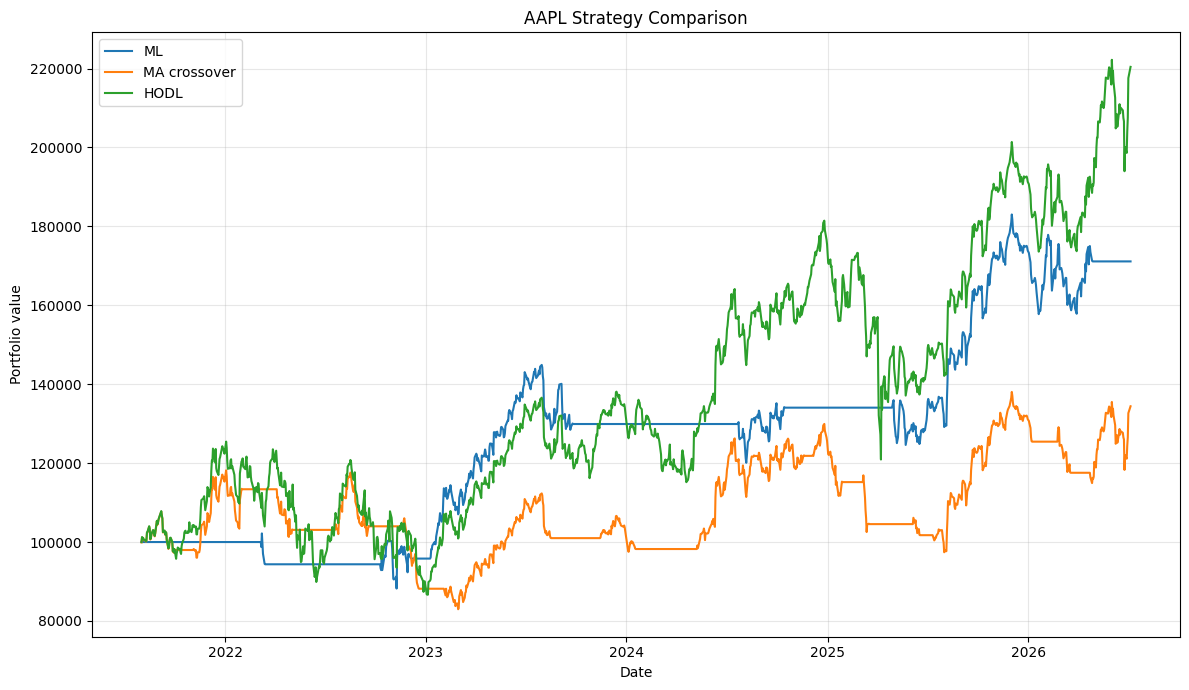

In [10]:
# ==========================================================
# CELL 8 — BACKTEST STRATEGIES
# ==========================================================

TRADING_DAYS_PER_YEAR = 252
TRANSACTION_COST = 0.001
# 0.001 = 0.10% whenever the position changes


# ----------------------------------------------------------
# Daily asset returns
# ----------------------------------------------------------

asset_return = (
    daily_close_bt
    .pct_change(fill_method=None)
    .fillna(0.0)
)





# ----------------------------------------------------------
# Run strategies
# ----------------------------------------------------------

bt_ml = backtest_position(
    asset_return=asset_return,
    position=position_ml_bt,
    starting_capital=starting_capital,
    transaction_cost=TRANSACTION_COST,
)

bt_q1 = backtest_position(
    asset_return=asset_return,
    position=position_q1_bt,
    starting_capital=starting_capital,
    transaction_cost=TRANSACTION_COST,
)

bt_hodl = backtest_position(
    asset_return=asset_return,
    position=position_hodl_bt,
    starting_capital=starting_capital,
    transaction_cost=0.0,
)





# ----------------------------------------------------------
# Comparison table
# ----------------------------------------------------------

performance = pd.DataFrame([
    performance_summary(
        bt_ml,
        "ML",
    ),
    performance_summary(
        bt_q1,
        "MA crossover",
    ),
    performance_summary(
        bt_hodl,
        "HODL",
    ),
]).set_index("strategy")


display(
    performance.style.format({
        "final_value": "${:,.0f}",
        "total_return": "{:.2%}",
        "CAGR": "{:.2%}",
        "annualized_volatility": "{:.2%}",
        "Sharpe": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "exposure": "{:.2%}",
        "entries": "{:,.0f}",
        "trade_events": "{:,.0f}",
        "total_cost": "{:.2%}",
    })
)


# ----------------------------------------------------------
# Equity curve
# ----------------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    bt_ml.index,
    bt_ml["equity"],
    label="ML",
)

plt.plot(
    bt_q1.index,
    bt_q1["equity"],
    label="MA crossover",
)

plt.plot(
    bt_hodl.index,
    bt_hodl["equity"],
    label="HODL",
)

plt.title(
    f"{ticker} Strategy Comparison"
)

plt.xlabel("Date")
plt.ylabel("Portfolio value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print("bt_ml identity check")
print("Start:", bt_ml.index.min())
print("End:", bt_ml.index.max())
print("Rows:", len(bt_ml))
print("Final equity:", bt_ml["equity"].iloc[-1])
print("Exposure:", bt_ml["position"].mean())
print("Trade events:", (bt_ml["turnover"] > 0).sum())
print("Total cost:", bt_ml["trading_cost"].sum())

bt_ml identity check
Start: 2021-08-02 00:00:00
End: 2026-07-06 00:00:00
Rows: 1236
Final equity: 171119.8201266333
Exposure: 0.4255663430420712
Trade events: 12
Total cost: 0.012


## 9. Benchmarks

In [12]:
# ==========================================================
# CELL 9 — BENCHMARK STRATEGY GENERATORS
# ==========================================================

N_RANDOM_SIMULATIONS = 1_000
RANDOM_SEED = 42

# Use the same per-side trading cost as Cell 8.
COST_PER_SIDE = TRANSACTION_COST

# Minimum future return required for the cost-aware Oracle.
#
# Example:
# 1% entry + 1% exit + 1% safety margin = 3%
ROUND_TRIP_HURDLE = (
    2 * COST_PER_SIDE
    + 0.01
)

DECISION_CLASSES = np.array(
    [-1, 0, 1],
    dtype=int,
)

decision_dates = (
    predictions["decision_date"]
    .sort_values()
    .drop_duplicates()
    .to_numpy()
)







# ----------------------------------------------------------
# Symmetric Markov random decisions
#
# Random with memory, but not calibrated to the ML model.
#
# There is a 70% chance of repeating the previous decision
# and a 15% chance of moving to either alternative.
# ----------------------------------------------------------

MARKOV_TRANSITION_MATRIX = np.array([
    # Next:   -1     0     +1
    [          0.70, 0.15, 0.15],  # Current -1
    [          0.15, 0.70, 0.15],  # Current  0
    [          0.15, 0.15, 0.70],  # Current +1
])

CLASS_TO_INDEX = {
    -1: 0,
     0: 1,
     1: 2,
}





# ----------------------------------------------------------
# Oracle benchmark
#
# Perfect knowledge of whether the next five-session return
# is positive or negative.
#
# The Oracle uses the same decision dates, execution delay,
# persistent-position logic and transaction costs as ML.
# ----------------------------------------------------------

oracle_data = (
    weekly_data[
        [
            "decision_date",
            "future_week_return",
        ]
    ]
    .copy()
    .set_index("decision_date")
    .reindex(
        pd.to_datetime(decision_dates)
    )
)

if oracle_data["future_week_return"].isna().any():
    raise ValueError(
        "Missing future returns on Oracle decision dates."
    )

oracle_decisions = (
    weekly_data
    .set_index("decision_date")
    .reindex(pd.to_datetime(decision_dates))["target"]
    .astype(int)
)

position_oracle_bt = (
    weekly_decisions_to_daily_position(
        decisions=oracle_decisions,
        daily_index=daily_close.index,
        backtest_index=backtest_index,
        initial_position=0,
    )
)

bt_oracle = backtest_position(
    asset_return=asset_return,
    position=position_oracle_bt,
    starting_capital=starting_capital,
    transaction_cost=TRANSACTION_COST,
)


print("\nBenchmark configuration")
print("=" * 60)
print(f"Random simulations:      {N_RANDOM_SIMULATIONS:,}")
print(f"Trading cost per side:   {COST_PER_SIDE:.2%}")
print(f"Oracle return hurdle:    {ROUND_TRIP_HURDLE:.2%}")
print(f"Weekly decision dates:   {len(decision_dates)}")


print("\nWeekly target thresholds")
print("=" * 60)
print(f"Buy  > {BUY_THRESHOLD:.1%}")
print(f"Sell < {SELL_THRESHOLD:.1%}")
print(f"Neutral otherwise")
print(f"Trading cost per side: {TRANSACTION_COST:.2%}")

print("\nOracle decision distribution:")
print("=" * 60)
print(
    oracle_decisions
    .value_counts(normalize=True)
    .sort_index()
)


Benchmark configuration
Random simulations:      1,000
Trading cost per side:   0.10%
Oracle return hurdle:    1.20%
Weekly decision dates:   258

Weekly target thresholds
Buy  > 3.0%
Sell < -2.0%
Neutral otherwise
Trading cost per side: 0.10%

Oracle decision distribution:
target
-1    0.248062
 0    0.523256
 1    0.228682
Name: proportion, dtype: float64


In [13]:
print("bt_ml identity check")
print("Start:", bt_ml.index.min())
print("End:", bt_ml.index.max())
print("Rows:", len(bt_ml))
print("Final equity:", bt_ml["equity"].iloc[-1])
print("Exposure:", bt_ml["position"].mean())
print("Trade events:", (bt_ml["turnover"] > 0).sum())
print("Total cost:", bt_ml["trading_cost"].sum())

bt_ml identity check
Start: 2021-08-02 00:00:00
End: 2026-07-06 00:00:00
Rows: 1236
Final equity: 171119.8201266333
Exposure: 0.4255663430420712
Trade events: 12
Total cost: 0.012


## 10. Random simulations and complete comparison

In [14]:
# ==========================================================
# CELL 10 — RANDOM BENCHMARK SIMULATIONS
# ==========================================================

rng_uniform = np.random.default_rng(
    RANDOM_SEED
)

rng_markov = np.random.default_rng(
    RANDOM_SEED + 1
)





uniform_random_results = (
    run_random_benchmark_simulations(
        generator_function=generate_uniform_random_decisions,
        rng=rng_uniform,
        benchmark_name="Uniform random",
        n_simulations=N_RANDOM_SIMULATIONS,
        decision_dates=decision_dates,
        daily_index=daily_close.index,
        backtest_index=backtest_index,
        asset_return=asset_return,
        starting_capital=starting_capital,
        transaction_cost=COST_PER_SIDE,
    )
)

markov_random_results = (
    run_random_benchmark_simulations(
        generator_function=generate_markov_random_decisions,
        rng=rng_markov,
        benchmark_name="Markov random",
        n_simulations=N_RANDOM_SIMULATIONS,
        decision_dates=decision_dates,
        daily_index=daily_close.index,
        backtest_index=backtest_index,
        asset_return=asset_return,
        starting_capital=starting_capital,
        transaction_cost=COST_PER_SIDE,
    )
)





uniform_random_summary = summarize_random_results(
    uniform_random_results,
    "Uniform random",
)

markov_random_summary = summarize_random_results(
    markov_random_results,
    "Markov random",
)

random_summary = pd.concat(
    [
        uniform_random_summary,
        markov_random_summary,
    ],
    ignore_index=True,
)


print("=" * 70)
print("RANDOM BENCHMARK DISTRIBUTIONS")
print("=" * 70)

display(
    random_summary
)





random_median_rows = pd.DataFrame([
    median_random_row(
        uniform_random_results,
        "Uniform random median",
        starting_capital,
    ),
    median_random_row(
        markov_random_results,
        "Markov random median",
        starting_capital,
    ),
]).set_index("strategy")


deterministic_performance = pd.DataFrame([
    performance_summary(bt_ml, "ML"),
    performance_summary(bt_q1, "MA crossover"),
    performance_summary(bt_hodl, "HODL"),
    performance_summary(bt_oracle, "Oracle"),
]).set_index("strategy")


benchmark_performance = pd.concat(
    [
        deterministic_performance,
        random_median_rows,
    ],
    axis=0,
)


print("\n" + "=" * 70)
print("COMPLETE BENCHMARK COMPARISON")
print("=" * 70)

display(
    benchmark_performance.style.format({
        "final_value": "${:,.0f}",
        "total_return": "{:.2%}",
        "CAGR": "{:.2%}",
        "annualized_volatility": "{:.2%}",
        "Sharpe": "{:.3f}",
        "max_drawdown": "{:.2%}",
        "exposure": "{:.2%}",
        "entries": "{:,.0f}",
        "trade_events": "{:,.0f}",
        "total_cost": "{:.2%}",
    })
)


# ----------------------------------------------------------
# ML percentile rank against random simulations
#
# 100% means ML beat every random simulation.
# ----------------------------------------------------------

ml_metrics = performance_summary(
    bt_ml,
    "ML",
)

percentile_rows = []

for benchmark_name, results in [
    (
        "Uniform random",
        uniform_random_results,
    ),
    (
        "Markov random",
        markov_random_results,
    ),
]:

    for metric in [
        "CAGR",
        "Sharpe",
        "max_drawdown",
        "final_value",
    ]:

        ml_value = ml_metrics[metric]

        percentile = (
            results[metric]
            .le(ml_value)
            .mean()
        )

        percentile_rows.append({
            "benchmark": benchmark_name,
            "metric": metric,
            "ML_value": ml_value,
            "ML_percentile": percentile,
        })


ml_random_percentiles = pd.DataFrame(
    percentile_rows
)


print("\n" + "=" * 70)
print("ML PERCENTILE RANK VERSUS RANDOM")
print("=" * 70)

display(
    ml_random_percentiles.style.format({
        "ML_value": "{:.4f}",
        "ML_percentile": "{:.2%}",
    })
)

RANDOM BENCHMARK DISTRIBUTIONS


,benchmark,metric,p05,median,mean,p95
0,Uniform random,final_value,80907.479110,131705.254733,140347.960011,220050.983406
1,Uniform random,CAGR,-0.042103,0.057506,0.063304,0.173660
2,Uniform random,Sharpe,-0.126312,0.386380,0.405466,0.925596
3,Uniform random,max_drawdown,-0.458873,-0.311433,-0.315991,-0.193319
4,Uniform random,exposure,0.426335,0.497573,0.497641,0.569620
5,Uniform random,entries,37.000000,43.000000,43.167000,49.000000
6,Uniform random,trade_events,74.000000,86.000000,85.832000,98.000000
7,Uniform random,total_cost,0.074000,0.086000,0.085832,0.098000
8,Markov random,final_value,91203.671487,142119.488309,147944.246084,227829.685529
9,Markov random,CAGR,-0.018520,0.073973,0.075609,0.181967



COMPLETE BENCHMARK COMPARISON


,final_value,total_return,CAGR,annualized_volatility,Sharpe,max_drawdown,exposure,entries,trade_events,total_cost
strategy,,,,,,,,,,
ML,"$171,120",71.12%,11.52%,15.89%,0.768,-17.12%,42.56%,6,12,1.20%
MA crossover,"$134,408",34.54%,6.21%,18.55%,0.418,-29.80%,58.74%,16,31,3.10%
HODL,"$220,422",120.42%,17.41%,27.87%,0.717,-33.36%,100.00%,1,1,0.00%
Oracle,"$1,949,260",1849.26%,82.76%,18.84%,3.309,-6.45%,48.14%,33,65,6.50%
Uniform random median,"$131,705",31.71%,5.75%,nan%,0.386,-31.14%,49.76%,43,86,8.60%
Markov random median,"$142,119",42.12%,7.40%,nan%,0.461,-30.26%,49.35%,20,39,3.90%



ML PERCENTILE RANK VERSUS RANDOM


,benchmark,metric,ML_value,ML_percentile
0,Uniform random,CAGR,0.1152,78.70%
1,Uniform random,Sharpe,0.7682,86.70%
2,Uniform random,max_drawdown,-0.1712,98.60%
3,Uniform random,final_value,171119.8201,78.70%
4,Markov random,CAGR,0.1152,74.30%
5,Markov random,Sharpe,0.7682,83.60%
6,Markov random,max_drawdown,-0.1712,97.80%
7,Markov random,final_value,171119.8201,74.30%


## 11. Equity curves

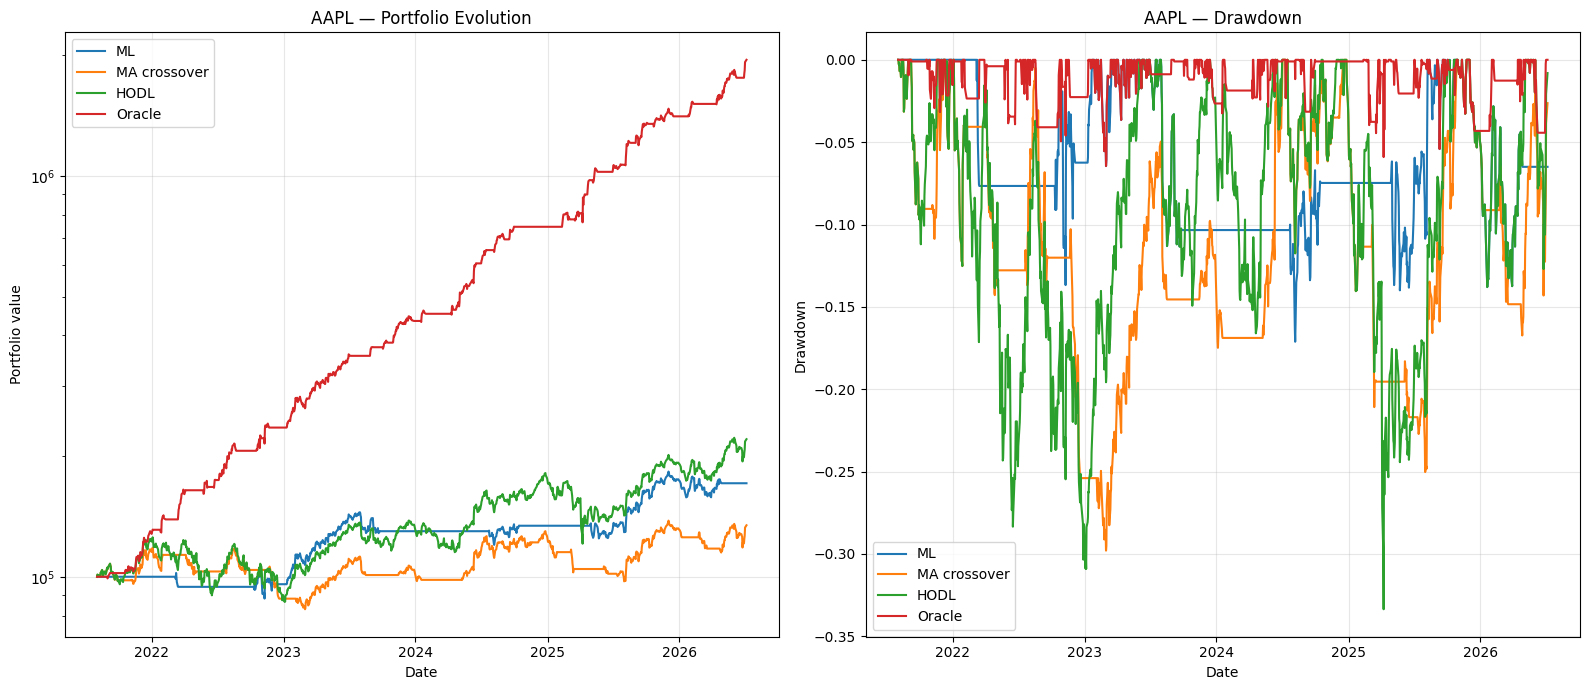

In [15]:
# ==========================================================
# BENCHMARK VISUALIZATION
# ==========================================================

PLOT_ANNUAL_RETURNS = False
USE_LOG_SCALE = True


# ----------------------------------------------------------
# Collect deterministic strategy results
# ----------------------------------------------------------

strategy_backtests = {
    "ML": bt_ml,
    "MA crossover": bt_q1,
    "HODL": bt_hodl,
    "Oracle": bt_oracle,
}


# ----------------------------------------------------------
# Equity and drawdown data
# ----------------------------------------------------------

equity_curves = pd.DataFrame({
    name: backtest["equity"]
    for name, backtest in strategy_backtests.items()
})

drawdown_curves = pd.DataFrame({
    name: backtest["drawdown"]
    for name, backtest in strategy_backtests.items()
})


# ----------------------------------------------------------
# Plot layout
# ----------------------------------------------------------

if PLOT_ANNUAL_RETURNS:

    figure, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(20, 7),
    )

    equity_axis = axes[0]
    drawdown_axis = axes[1]
    annual_axis = axes[2]

else:

    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(16, 7),
    )

    equity_axis = axes[0]
    drawdown_axis = axes[1]


# ----------------------------------------------------------
# Equity curves
# ----------------------------------------------------------

for strategy_name in equity_curves.columns:

    equity_axis.plot(
        equity_curves.index,
        equity_curves[strategy_name],
        label=strategy_name,
    )

equity_axis.set_title(
    f"{ticker} — Portfolio Evolution"
)

equity_axis.set_xlabel("Date")
equity_axis.set_ylabel("Portfolio value")

if USE_LOG_SCALE:
    equity_axis.set_yscale("log")

equity_axis.legend()
equity_axis.grid(
    alpha=0.3
)


# ----------------------------------------------------------
# Drawdown curves
# ----------------------------------------------------------

for strategy_name in drawdown_curves.columns:

    drawdown_axis.plot(
        drawdown_curves.index,
        drawdown_curves[strategy_name],
        label=strategy_name,
    )

drawdown_axis.set_title(
    f"{ticker} — Drawdown"
)

drawdown_axis.set_xlabel("Date")
drawdown_axis.set_ylabel("Drawdown")

drawdown_axis.legend()
drawdown_axis.grid(
    alpha=0.3
)


# ----------------------------------------------------------
# Optional annual returns
# ----------------------------------------------------------

if PLOT_ANNUAL_RETURNS:

    annual_returns = pd.DataFrame({
        strategy_name: (
            backtest["equity"]
            .resample("YE")
            .last()
            .pct_change()
        )
        for strategy_name, backtest
        in strategy_backtests.items()
    })

    annual_returns.index = (
        annual_returns.index.year
    )

    annual_returns.plot(
        kind="bar",
        ax=annual_axis,
    )

    annual_axis.axhline(
        0,
        linewidth=1,
        linestyle="--",
    )

    annual_axis.set_title(
        f"{ticker} — Annual Returns"
    )

    annual_axis.set_xlabel("Year")
    annual_axis.set_ylabel("Return")

    annual_axis.legend()


plt.tight_layout()
plt.show()